# **Duolingo's User Insights**

Duolingo is an educational application which provides users to learn different kind of
languages on the platform for free.

#**Problem Statement:**

Duolingo wants to launch new features to make learning more fun and engaging by analyzing how users learn and progress on the platform in order to boost overall platform engagement and learning success rate. One of these features is "Week in Review", which will show key details about each user and compare them to trends across the platform. It’s similar to Spotify or YouTube “Year in
Review."

#**Analysis Approach:**

**1.Understand the Problem:** Define key questions and review the dataset to grasp the problem of viewer churn and engagement.

**2.Define Metrics and Hypotheses:** Identify metrics like views, likes, and watch time. Formulate hypotheses, e.g., "Higher watch time leads to lower churn."

**3.Data Cleaning:** Handle missing, duplicate, or inconsistent data. Standardize formats and remove outliers.

**4.Exploratory Data Analysis(EDA):** Visualize trends in engagement metrics, content types, and viewer demographics.

**5.Visualization:** Using correct graphs, etc. for the better and easy understanding.

**6.Create Tableau Dashboard and Storyboard:** With the key metrics and their relationships build a dashboard with interactive filters and a storyboard telling the details of the visualizations.

# **Dataset:**

This dataset contains list of users and their engagement in this app.

Dataset name: duolingo_data.csv                                     
Number of rows: 3795780                                             
Number of columns: 12

The columns in this dataset:

**1.p_recall:** The proportion of exercises in this lesson where the word (or lexeme) was correctly recalled by the student.

**2.timestamp:** Indicates when the current lesson or practice took place.

**3.delta:** The time (in seconds) since the last lesson or practice where this specific word (lexeme) was encountered.

**4.user_id:** An anonymized ID representing the student who completed the lesson or practice.

**5.Learning_language:** The target language that the student is learning.

**6.ui_language:** The language of the app’s user interface, which is usually the student's native language.

**7.lexeme_id:** A system-generated unique ID for the word or lexeme being practiced.

**8.lexeme_string:** A detailed grammar tag describing the lexeme (word), including its properties like tense, gender, and plurality.

**9.history_seen:** The total number of times the student has encountered this word (lexeme) in lessons or practice sessions before this one.

**10.history_correct:** The total number of times the student correctly recalled this word (lexeme) in previous lessons or practice sessions.

**11.session_seen:** This column indicates how many times the student encountered the specific word or lexeme during the current lesson or practice session.

**12.session_correct:** This column indicates how many times the student correctly recalled or answered the specific word or lexeme during the current lesson or practice session.


#**Data Analisis and Visualization**

**Download the dataset and import all the libraries that will be used.**

In [ ]:
# Step 1: Install gdown
!pip install gdown

# Step 2: Import the file from Google Drive
import gdown

# File ID and URL
file_id = "1Jhl4lWVCMsvuWzTVY7hYCE88AMv-f1-7"
url = f"https://drive.google.com/uc?id={file_id}"

# Output file name
output = "duolingo_data.csv"

# Step 3: Download the file
gdown.download(url, output, quiet=False)

# Step 4: Load the file into a DataFrame
import pandas as pd
data = pd.read_csv(output)

Downloading...
From (original): https://drive.google.com/uc?id=1Jhl4lWVCMsvuWzTVY7hYCE88AMv-f1-7
From (redirected): https://drive.google.com/uc?id=1Jhl4lWVCMsvuWzTVY7hYCE88AMv-f1-7&confirm=t&uuid=a159de7a-11b3-4150-a3db-45ebb69f5b7d
To: /content/duolingo_data.csv
100%|██████████| 409M/409M [00:05<00:00, 75.2MB/s]


In [ ]:
     #library for mathmetic functins
import numpy as np
    #library for dataframes or tables
import pandas as pd
    #library for visualization functins(charts,graphs)
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

data=pd.read_csv('duolingo_data.csv')
print(data.iloc[:5,:].head().to_string())

   p_recall            timestamp    delta user_id learning_language ui_language                         lexeme_id                    lexeme_string  history_seen  history_correct  session_seen  session_correct
0       1.0  2013-03-03 17:13:47  1825254     5C7                fr          en  3712581f1a9fbc0894e22664992663e9                      sur/sur<pr>             2                1             2                2
1       1.0  2013-03-04 18:30:50      367    fWSx                en          es  0371d118c042c6b44ababe667bed2760             police/police<n><pl>             6                5             2                2
2       0.0  2013-03-03 18:35:44     1329    hL-s                de          en  5fa1f0fcc3b5d93b8617169e59884367  hat/haben<vbhaver><pri><p3><sg>            10               10             1                0
3       1.0  2013-03-07 17:56:03      156    h2_R                es          en  4d77de913dc3d65f1c9fac9d1c349684                        en/en<pr>           111    

In [ ]:
data.shape   #shows the total number oF rows and columns in the dataset

(3795780, 12)

In [ ]:
data.head()  #shows the data of top 5 rows of the dataset

,p_recall,timestamp,delta,user_id,learning_language,ui_language,lexeme_id,lexeme_string,history_seen,history_correct,session_seen,session_correct
0,1.0,2013-03-03 17:13:47,1825254,5C7,fr,en,3712581f1a9fbc0894e22664992663e9,sur/sur<pr>,2,1,2,2
1,1.0,2013-03-04 18:30:50,367,fWSx,en,es,0371d118c042c6b44ababe667bed2760,police/police<n><pl>,6,5,2,2
2,0.0,2013-03-03 18:35:44,1329,hL-s,de,en,5fa1f0fcc3b5d93b8617169e59884367,hat/haben<vbhaver><pri><p3><sg>,10,10,1,0
3,1.0,2013-03-07 17:56:03,156,h2_R,es,en,4d77de913dc3d65f1c9fac9d1c349684,en/en<pr>,111,99,4,4
4,1.0,2013-03-05 21:41:22,257,eON,es,en,35f14d06d95a34607d6abb0e52fc6d2b,caballo/caballo<n><m><sg>,3,3,3,3


#**PART 1: DATA CLEANING**

**1.Inspecting missing data**

In [ ]:
missing_values=data.isnull().sum()     #Shows the total number of missing values in the each column
print(missing_values)

p_recall             0
timestamp            0
delta                0
user_id              0
learning_language    0
ui_language          0
lexeme_id            0
lexeme_string        0
history_seen         0
history_correct      0
session_seen         0
session_correct      0
dtype: int64


**As there are no missing values found, there is no need to fill or delete any rows or columns.**

**2.Inspecting data types**

In [ ]:
data.dtypes     #shows the data types of each of the column

,0
p_recall,float64
timestamp,object
delta,int64
user_id,object
learning_language,object
ui_language,object
lexeme_id,object
lexeme_string,object
history_seen,int64
history_correct,int64


**The data type for timestamp is not the correct data type so we have to change the data type of that column (i.e., object to datetime64[ns])**

In [ ]:

data['timestamp'] = pd.to_datetime(data['timestamp'], errors='coerce')  #converts the datatype for timestamp column into its appropriate data type
data.dtypes


,0
p_recall,float64
timestamp,datetime64[ns]
delta,int64
user_id,object
learning_language,object
ui_language,object
lexeme_id,object
lexeme_string,object
history_seen,int64
history_correct,int64


#**Part 2: Data Processing**

**Grouping**

In [ ]:
data['session_accuracy'] = data['session_correct'] / data['session_seen']   # creates a new column called session accuracy to check the accurate values by combining session_seen and session_correct
data.head()


,p_recall,timestamp,delta,user_id,learning_language,ui_language,lexeme_id,lexeme_string,history_seen,history_correct,session_seen,session_correct,session_accuracy
0,1.0,2013-03-03 17:13:47,1825254,5C7,fr,en,3712581f1a9fbc0894e22664992663e9,sur/sur<pr>,2,1,2,2,1.0
1,1.0,2013-03-04 18:30:50,367,fWSx,en,es,0371d118c042c6b44ababe667bed2760,police/police<n><pl>,6,5,2,2,1.0
2,0.0,2013-03-03 18:35:44,1329,hL-s,de,en,5fa1f0fcc3b5d93b8617169e59884367,hat/haben<vbhaver><pri><p3><sg>,10,10,1,0,0.0
3,1.0,2013-03-07 17:56:03,156,h2_R,es,en,4d77de913dc3d65f1c9fac9d1c349684,en/en<pr>,111,99,4,4,1.0
4,1.0,2013-03-05 21:41:22,257,eON,es,en,35f14d06d95a34607d6abb0e52fc6d2b,caballo/caballo<n><m><sg>,3,3,3,3,1.0


In [ ]:
data.head()

,p_recall,timestamp,delta,user_id,learning_language,ui_language,lexeme_id,lexeme_string,history_seen,history_correct,session_seen,session_correct,session_accuracy
0,1.0,2013-03-03 17:13:47,1825254,5C7,fr,en,3712581f1a9fbc0894e22664992663e9,sur/sur<pr>,2,1,2,2,1.0
1,1.0,2013-03-04 18:30:50,367,fWSx,en,es,0371d118c042c6b44ababe667bed2760,police/police<n><pl>,6,5,2,2,1.0
2,0.0,2013-03-03 18:35:44,1329,hL-s,de,en,5fa1f0fcc3b5d93b8617169e59884367,hat/haben<vbhaver><pri><p3><sg>,10,10,1,0,0.0
3,1.0,2013-03-07 17:56:03,156,h2_R,es,en,4d77de913dc3d65f1c9fac9d1c349684,en/en<pr>,111,99,4,4,1.0
4,1.0,2013-03-05 21:41:22,257,eON,es,en,35f14d06d95a34607d6abb0e52fc6d2b,caballo/caballo<n><m><sg>,3,3,3,3,1.0


In [ ]:
data.to_csv('duolingo_data.csv', index=False)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3795780 entries, 0 to 3795779
Data columns (total 13 columns):
 #   Column             Dtype         
---  ------             -----         
 0   p_recall           float64       
 1   timestamp          datetime64[ns]
 2   delta              int64         
 3   user_id            object        
 4   learning_language  object        
 5   ui_language        object        
 6   lexeme_id          object        
 7   lexeme_string      object        
 8   history_seen       int64         
 9   history_correct    int64         
 10  session_seen       int64         
 11  session_correct    int64         
 12  session_accuracy   float64       
dtypes: datetime64[ns](1), float64(2), int64(5), object(5)
memory usage: 376.5+ MB


In [ ]:
data[['p_recall', 'delta', 'history_seen','history_correct','session_seen','session_correct']].describe()    #checking for the outliers

,p_recall,delta,history_seen,history_correct,session_seen,session_correct
count,3.795780e+06,3.795780e+06,3.795780e+06,3.795780e+06,3.795780e+06,3.795780e+06
mean,8.964675e-01,7.055116e+05,2.197719e+01,1.949662e+01,1.808655e+00,1.636209e+00
std,2.711188e-01,2.211979e+06,1.283616e+02,1.136178e+02,1.350644e+00,1.309628e+00
min,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00
25%,1.000000e+00,5.180000e+02,3.000000e+00,3.000000e+00,1.000000e+00,1.000000e+00
50%,1.000000e+00,7.609500e+04,6.000000e+00,6.000000e+00,1.000000e+00,1.000000e+00
75%,1.000000e+00,4.346412e+05,1.500000e+01,1.300000e+01,2.000000e+00,2.000000e+00
max,1.000000e+00,3.964973e+07,1.344200e+04,1.281600e+04,2.000000e+01,2.000000e+01


#**PART 3 : DATA ANALYSIS**

**1.Engagement Analysis**

   **Hypothesis 1:** What is the recall accuracy of the users who practice most frequently?

  

In [ ]:
user_practice = data.groupby('user_id').agg({
    'delta': 'mean',
    'p_recall': 'mean'
}).reset_index()

correlation_delta_recall = user_practice['delta'].corr(user_practice['p_recall'])
print("Correlation between delta and recall accuracy:" ,correlation_delta_recall)

Correlation between delta and recall accuracy: -0.07888060432791903


 **Output:** here the the users (which is here grouped as user_id) who practice more frequently (delta i.e., who has shorter delta value) have higher recall accuracy.

**Hypothesis 2:** What is the accuracy of the user engageed over time ?
    

In [ ]:
data['date'] = data['timestamp'].dt.date
user_engagement = data.groupby('user_id').agg({
    'date': 'nunique',
    'history_correct': 'sum',
    'history_seen': 'sum'
}).reset_index()

user_engagement['cumulative_accuracy'] = user_engagement['history_correct'] / user_engagement['history_seen']

correlation_active_days_accuracy = user_engagement['date'].corr(user_engagement['cumulative_accuracy'])
print("Correlation between active days and cumulative accuracy: ",correlation_active_days_accuracy)

Correlation between active days and cumulative accuracy:  0.06644845619084934


**Output:** Here the users who are more active in days have the higher cummulative accuracy (difference between the history_seen and history_correct)

 #**2.Learning Success Analysis:**

**Hypothesis 1:** What is the progress of learining of the users by time ?

In [ ]:
daily_progress = data.groupby(data['timestamp'].dt.date).agg({'p_recall': 'mean'}).reset_index()
print(daily_progress.head())

    timestamp  p_recall
0  2013-03-01  0.895310
1  2013-03-02  0.897230
2  2013-03-03  0.895920
3  2013-03-04  0.896910
4  2013-03-05  0.896474


**Output:** Here it shows the users correct recall of the wrod(lexeme) in a lesson over a time period.

**Hypothesis 2:** What is the recall accuracy of the lexeme(word)?

In [ ]:
lexeme_repeted = data.groupby('lexeme_string').agg({
    'history_seen': 'sum',
    'history_correct': 'sum'
}).reset_index()

lexeme_repeted['recall_accuracy'] = lexeme_repeted['history_correct'] / lexeme_repeted['history_seen']

correlation_lexeme_recall = lexeme_repeted['history_seen'].corr(lexeme_repeted['recall_accuracy'])
print("Correlation between history_seen and recall accuracy: ",correlation_lexeme_recall)

Correlation between history_seen and recall accuracy:  0.001616856728345985


**Output:** Here it shows the word (lexeme) repeated (recall)before the current lesson (i.e., history_seen and history_correct)

**Hypothesis 3:** What is the learnining progress of the users by how frequently they are visiting the session?

In [ ]:
user_frequency = data.groupby('user_id').agg({
    'delta': 'mean',
    'history_correct': 'sum',
    'history_seen': 'sum'
}).reset_index()

user_frequency['cumulative_accuracy'] = user_frequency['history_correct'] / user_frequency['history_seen']

correlation_delta_cumulative = user_frequency['delta'].corr(user_frequency['cumulative_accuracy'])
print("Correlation between delta and cumulative accuracy: ",correlation_delta_cumulative)

Correlation between delta and cumulative accuracy:  0.035299646579048556


**Output:** This code shows the users progress of learning the language by comparing it with how they are frequrntly visiting the sessions.

#**3.Language and Platform Trends Analysis:**

**Hypothesis 1:** What is the difficulty levels of the languages among the users.

In [ ]:
language_difficulty = data.groupby('learning_language')['p_recall'].mean().reset_index()
print(language_difficulty)

  learning_language  p_recall
0                de  0.892481
1                en  0.898900
2                es  0.898845
3                fr  0.882756
4                it  0.907550
5                pt  0.903441


**Output:** This code shows the difficulty level of the users in the process of learing a language by how many time they are taking to complete a lesson.

**Hypothesis 2:** What is the impact of the User Interface Language causes on the learning language?

In [ ]:
ui_language_impact = data.groupby(['ui_language', 'learning_language'])['p_recall'].mean().reset_index()
print(ui_language_impact)

  ui_language learning_language  p_recall
0          en                de  0.892481
1          en                es  0.898845
2          en                fr  0.882756
3          en                it  0.907550
4          en                pt  0.903441
5          es                en  0.898155
6          it                en  0.908159
7          pt                en  0.897696


**Output:** This code shows how the user interface language is impacting the user to learn the language they have choosen i.e., if the user interface language makes the user to understand the learning language better or not.

**Hypothesis 3:** What is the popular language among the user ?

In [ ]:
language_trends = data.groupby('learning_language').agg({
    'session_seen': 'sum',
    'p_recall': 'mean'
}).reset_index()
print(language_trends)

  learning_language  session_seen  p_recall
0                de        757359  0.892481
1                en       2716155  0.898900
2                es       1805186  0.898845
3                fr       1027550  0.882756
4                it        402770  0.907550
5                pt        156236  0.903441


**Output:** This code gives the languages that are popular among the user by calculating how frequently the users are recalling the words or how long they are spending their time in a particular language.

# **4.User Behaviour Analysis**

**Hypothesis 1:** What is the cummulative accuracy of the users engagement?

In [ ]:
user_behavior = data.groupby('user_id').agg({
    'session_seen': 'sum',
    'history_correct': 'sum',
    'history_seen': 'sum'
}).reset_index()

user_behavior['cumulative_accuracy'] = user_behavior['history_correct'] / user_behavior['history_seen']

correlation_engagement_accuracy = user_behavior['session_seen'].corr(user_behavior['cumulative_accuracy'])
print("Correlation between session_seen and cumulative accuracy: ",correlation_engagement_accuracy)

Correlation between session_seen and cumulative accuracy:  0.06514007500602051


**Output:** Shows the higher cummulative accuracy ( history_correct/history_seen) by the session_seen by the engaged users.

**Hypothesis 2:** What is the learning success of the users

In [ ]:
performance_consistency = data.groupby('user_id').agg({
    'session_accuracy': 'std',
    'p_recall': 'mean'
}).reset_index()

correlation_consistency_recall = performance_consistency['session_accuracy'].corr(performance_consistency['p_recall'])
print("Correlation between std of session_accuracy and recall accuracy:",correlation_consistency_recall)

Correlation between std of session_accuracy and recall accuracy: -0.7522768359836207


**Output:** This shows the higher learning success(p_recall) by the session accuracy(session_correct/session_seen) ny the user

# **PART 4 : DATA VISUALIZATION**

**1. Daily Engagement**

         

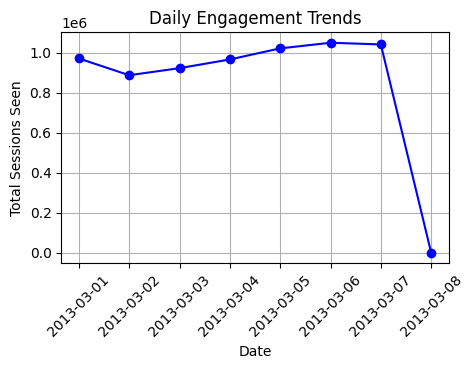

In [ ]:
daily_engagement = data.groupby(data['timestamp'].dt.date)['session_seen'].sum()

plt.figure(figsize=(5, 3))
daily_engagement.plot(marker='o', color='blue')
plt.title('Daily Engagement Trends')
plt.xlabel('Date')
plt.ylabel('Total Sessions Seen')
plt.xticks(rotation=45)
plt.grid()
plt.show()

**2. Language Engagement**

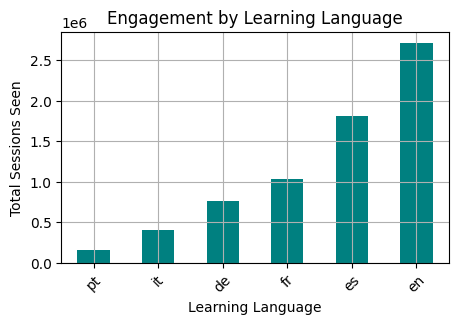

In [ ]:
language_engagement = data.groupby('learning_language')['session_seen'].sum()

plt.figure(figsize=(5, 3))
language_engagement.sort_values().plot(kind='bar', color='teal')
plt.title('Engagement by Learning Language')
plt.xlabel('Learning Language')
plt.ylabel('Total Sessions Seen')
plt.xticks(rotation=45)
plt.grid()
plt.show()

**3.Recall Accuracy**

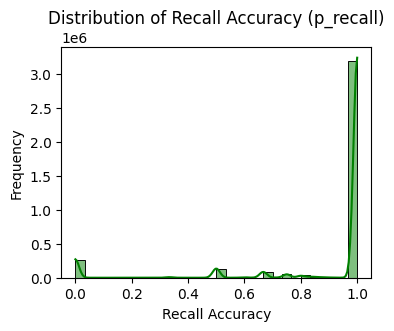

In [ ]:
plt.figure(figsize=(4, 3))
sns.histplot(data['p_recall'], kde=True, bins=30, color='green')
plt.title('Distribution of Recall Accuracy (p_recall)')
plt.xlabel('Recall Accuracy')
plt.ylabel('Frequency')
plt.show()

**4.Learning Language Performance**

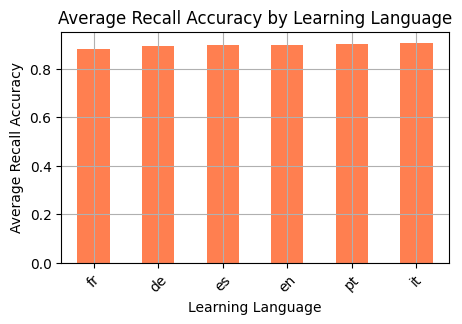

In [ ]:
language_performance = data.groupby('learning_language')['p_recall'].mean()

plt.figure(figsize=(5, 3))
language_performance.sort_values().plot(kind='bar', color='coral')
plt.title('Average Recall Accuracy by Learning Language')
plt.xlabel('Learning Language')
plt.ylabel('Average Recall Accuracy')
plt.xticks(rotation=45)
plt.grid()
plt.show()

**5.Engagement vs Cummulative accuracy**

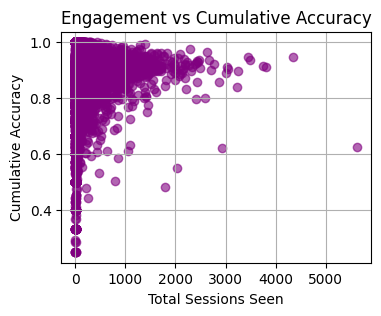

In [ ]:
user_engagement = data.groupby('user_id').agg({
    'session_seen': 'sum',
    'history_correct': 'sum',
    'history_seen': 'sum'
}).reset_index()

user_engagement['cumulative_accuracy'] = user_engagement['history_correct'] / user_engagement['history_seen']

plt.figure(figsize=(4, 3))
plt.scatter(user_engagement['session_seen'], user_engagement['cumulative_accuracy'], alpha=0.6, color='purple')
plt.title('Engagement vs Cumulative Accuracy')
plt.xlabel('Total Sessions Seen')
plt.ylabel('Cumulative Accuracy')
plt.grid()
plt.show()


**6.Relationship between key matrics**

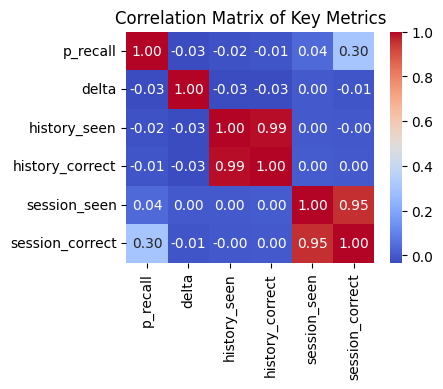

In [ ]:
correlation_matrix = data[['p_recall', 'delta', 'history_seen','history_correct', 'session_seen','session_correct']].corr()

plt.figure(figsize=(4, 3))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Key Metrics')
plt.show()

#**key Insights:**

1.Users who practice regularly stay more engaged in short sessions.

2.Short term performance is better than long term retention that users forget lessons without revision.

3.Long gap between sessions reduce accuracy and recall.

4.Some languages are easier to learn,with corrections.

5.Users who revisit old lessons tend to stay longer.

# **Recommendations:**

1.Introduce revision reminders for the users who arent active for long.

2.Introduce daily short practice sessions to the users.

3.Personalize lesson difficulty based on user performance.

4.Provide extra support for difficult languages.

5.Provide additional notes for the users.
